In [18]:
# torch → pour utiliser le Deep Learning
# torchvision → pour charger des modèles CNN et traiter les images
# matplotlib → pour afficher les images
# opencv-python → pour créer et superposer la heatmap

!pip install torch torchvision matplotlib opencv-python

In [19]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [20]:
# On charge le modèle ResNet50 déjà entraîné
# le modèle a déjà appris sur le dataset ImageNet
# il sait reconnaître 1000 classes d’objets
model = models.resnet50(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [21]:
# transformations à appliquer à l’image
transform = transforms.Compose([

    # Redimensionner l’image à 224x224 pixels
    # (taille attendue par ResNet50)
    transforms.Resize((224, 224)),

    # Convertir l’image en tenseur PyTorch
    # (format numérique utilisable par le modèle)
    transforms.ToTensor(),

    # Normaliser les pixels avec les moyennes et écarts-types d’ImageNet
    # Cela permet d’adapter l’image au modèle pré-entraîné
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
# Charger l’image "image.png"
# convert("RGB") garantit que l’image a bien 3 canaux (Rouge, Vert, Bleu)
img = Image.open("image.png").convert("RGB")

# Appliquer les transformations définies
# unsqueeze(0) ajoute une dimension batch (obligatoire pour le modèle)
# Format final : (1, 3, 224, 224)
input_tensor = transform(img).unsqueeze(0)

In [22]:
gradients = None
# activations → pour stocker les feature maps Ak
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# Dernière couche convolutionnelle de ResNet50
target_layer = model.layer4[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [23]:
# On passe l’image dans le modèle → on obtient les scores
output = model(input_tensor)
# On choisit la classe prédite
pred_class = output.argmax(dim=1).item()

In [24]:
# Réinitialiser les gradients
model.zero_grad()
# Sélectionner le score de la classe prédite
class_score = output[0, pred_class]
# Backward Pass : calcul des gradients
class_score.backward()

In [25]:
# On calcule la moyenne globale des gradients pour chaque feature map
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

In [26]:
# Pour chaque feature map, on multiplie tous ses pixels par son poids calculé
# Cela permet de donner plus d’importance aux feature maps qui contribuent le plus à la classe prédite
for i in range(activations.shape[1]):
    activations[:, i, :, :] *= pooled_gradients[i]
# Résultat : une seule "carte" 2D qui résume l'importance spatiale

heatmap = torch.mean(activations, dim=1).squeeze()
# On applique ReLU pour ne garder que les valeurs positives
heatmap = F.relu(heatmap)

In [27]:
# Normaliser la heatmap pour que ses valeurs soient entre 0 et 1
# Cela facilite l’affichage et la superposition sur l’image originale
heatmap /= torch.max(heatmap)

# Convertir la heatmap de tenseur PyTorch en tableau NumPy
# Cela permet de l’utiliser avec OpenCV ou matplotlib pour l’affichage
heatmap = heatmap.detach().numpy()

In [28]:
img_cv = cv2.imread("image.png")

# Redimensionner la heatmap à la taille de l’image originale
heatmap = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))

# Convertir les valeurs de la heatmap en entiers 0-255
heatmap = np.uint8(255 * heatmap)

# Appliquer un dégradé de couleur (rouge/jaune/bleu) pour visualiser l’importance
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superposer la heatmap sur l’image originale
superimposed_img = heatmap * 0.4 + img_cv

# Sauvegarder le résultat final
cv2.imwrite("gradcam_result.jpg", superimposed_img)

True

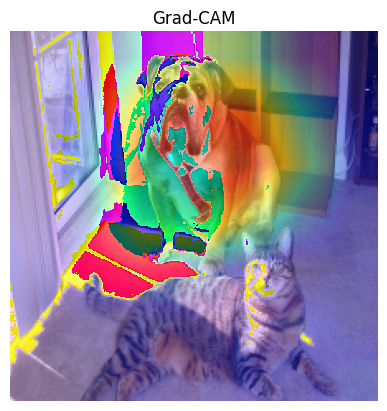

In [29]:
# Convertir l’image de BGR (OpenCV) en RGB (matplotlib utilise RGB)
plt.imshow(cv2.cvtColor(superimposed_img.astype(np.uint8), cv2.COLOR_BGR2RGB))

# Supprimer les axes pour une meilleure visualisation
plt.axis("off")

# Ajouter un titre à l’image
plt.title("Grad-CAM")

# Afficher l’image finale avec la heatmap superposée
plt.show()